# DeepSeek-V4.1-Flash (EXL3 3.0 bpw) on 4× CMP 170HX: TP4 + EP4, every expert in VRAM, DSpark

| Metric (measured) | No drafter | DSpark k=5 |
|---|---:|---:|
| Decode, 1 user, structured / code / prose (tok/s) | 25.4 / 25.4 / 12.1 | **99.5 / 48.9** / 10.0 |
| Decode, 4 users aggregate, structured / code / prose (tok/s) | 78.3 / 73.0 / 40.7 | **214.1 / 128.2** / 49.0 |
| Edit reply (rename a class in a 500-line file, 4,720 tokens) | 25.1 tok/s | **49.5 tok/s**, byte-identical reply |
| Known-answer checks | 5 / 5 | 5 / 5 |
| Prefill, 7k–51k prompt tokens | 110–173 tok/s (Engram on disk) | not re-measured |

![decode, no drafter vs DSpark](../assets/charts/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm.png)

All 384 routed experts of the 3.0 bpw EXL3 checkpoint stay resident on four 64 GiB cards (52.2 GiB each), split by expert parallelism (96 whole experts per card) under tensor parallelism 4. A single-card host-offload run of the same checkpoint on this host decoded at about 7 tok/s (separate run, receipts not in this folder). Prose and prefill are held back by the Engram n-gram tables, which this recipe reads from NVMe (section 3).

```
docker pull ghcr.io/pixelml/club-170hx@sha256:ffba0e15b5295204a3860fae7ba93fd70fe94d824f79baa1340ab71fa1f451f8
```

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
LIVE = False  # True sends the final request to the endpoint in DSV41_URL (an OpenAI-compatible /v1 base)
ENDPOINT_ENV_VAR = "DSV41_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/receipts


In [2]:
# --- Helpers: receipts, tables, chart style ---
import json, csv, statistics, datetime
from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot as plt

def receipt(*parts):
    with open("/".join([RECEIPTS, *parts])) as f:
        return json.load(f)

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

INK, INK2, GRID = "#1f2328", "#57606a", "#d0d7de"
S = ["#0969da", "#cf222e", "#8250df", "#1a7f37"]
matplotlib.rcParams.update({"axes.edgecolor": GRID, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                            "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
                            "axes.spines.right": False, "font.size": 9})

def label_bars(ax, bars, fmt="{:.1f}"):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), fmt.format(b.get_height()), ha="center", va="bottom", color=INK2, fontsize=7)

## 1. TL;DR

- **Measured:** DeepSeek-V4.1-Flash serves on 4× CMP 170HX with tensor parallelism 4 and expert parallelism 4. Each card holds 96 whole routed experts and a replicated shared expert; 52.2 GiB of weights per card (54.4 GiB with the DSpark layers); the fp8 KV pool at a 65,536 context is 570,145 tokens without the drafter and 263,972 with DSpark k=5 (4.0 concurrent full-length requests).
- **Measured:** five greedy known-answer prompts pass with and without the drafter. DSpark verifies every draft, and the edit reply is byte-identical with and without it.
- **Measured:** DSpark k=5 (the checkpoint's own MTP layers) takes one user from 25.4 to 99.5 tok/s on structured text (4.97 of 5 drafts accepted) and to 48.9 on code (3.71 of 5). Four users reach 214.1 / 128.2 tok/s.
- **Measured:** k=10 (two chained DSpark passes; DSpark drafts in multiples of 5, so k=7 is rejected) is worse: 55.5 tok/s structured for one user and 45.0 aggregate for four.
- **Measured:** prose and prefill are slow because the 189 GiB Engram tables are read from NVMe on every step. During prefill the GPUs sat near 10% utilization. Pre-loading about half the tables into the page cache doubled prefill (k=10 run, section 3).
- **Inferred:** keeping the Engram tables in RAM (for example tmpfs) should lift prose and prefill. Not measured here.

In [3]:
pins = {
    "served image": "ghcr.io/pixelml/club-170hx@sha256:ffba0e15b5295204a3860fae7ba93fd70fe94d824f79baa1340ab71fa1f451f8",
    "base image": "ghcr.io/pixelml/club-170hx@sha256:75683c4813efaabcc1a96ee610a96a74336677c4a8776b79b01abd83ff3c0c7b (0xSero/dsv41-flash-offload @ 2e9da5ecdab37c232c2da887e25c33a99da738d3, docker/Dockerfile, --build-arg TORCH_CUDA_ARCH_LIST=8.0)",
    "base recipe pins": "lazymio/vllm-backport@sha256:349690323ab9aba712111529ed1ca60730199205d8202f67895ffde85b451be3; Tokha233 a100-turbo fae324ae62ac5cef31b7d38f5d369618e1cae1fa; exllamav3 5be886578ec80324c2c715269387be2058724b6e; vllm-exl3 d3cfd394920360d69f820d2dc96f8292a9e10283",
    "our changes": "results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/build (Dockerfile, 4 patched files, launch.sh; diffs in build/patches)",
    "EXL3 checkpoint": "Mia-AiLab/DeepSeek-V4.1-Flash-EXL3-3.0bpw @ c5534b90602b4090980a1c3ded1eb3b4d99a38d5 (MIT)",
    "Engram tables": "deepseek-ai/DeepSeek-V4.1-Flash @ 2cba9e42aa026125f3ed06c6d98c1db82f7ca027, shards 47-48 (MIT)",
    "pack": "built by the base image: docker run ... <base image> prepare (overlay pack DSV41-EXL3-3090-D010)",
    "drafter": "DSpark from the checkpoint's mtp.0-2 layers (4 bpw), num_speculative_tokens 5",
    "driver": "NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB unlock); peer-to-peer not used by this run",
    "host": "Proxmox VE 9.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver",
    "topology": "4 cards, PCIe Gen2: three x16, one x8 during these runs; 140 W power cap; custom all-reduce off (NCCL)",
    "context": "65,536 tokens, fp8 KV, 4 sequences",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| served image | ghcr.io/pixelml/club-170hx@sha256:ffba0e15b5295204a3860fae7ba93fd70fe94d824f79baa1340ab71fa1f451f8 |
| base image | ghcr.io/pixelml/club-170hx@sha256:75683c4813efaabcc1a96ee610a96a74336677c4a8776b79b01abd83ff3c0c7b (0xSero/dsv41-flash-offload @ 2e9da5ecdab37c232c2da887e25c33a99da738d3, docker/Dockerfile, --build-arg TORCH_CUDA_ARCH_LIST=8.0) |
| base recipe pins | lazymio/vllm-backport@sha256:349690323ab9aba712111529ed1ca60730199205d8202f67895ffde85b451be3; Tokha233 a100-turbo fae324ae62ac5cef31b7d38f5d369618e1cae1fa; exllamav3 5be886578ec80324c2c715269387be2058724b6e; vllm-exl3 d3cfd394920360d69f820d2dc96f8292a9e10283 |
| our changes | results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/build (Dockerfile, 4 patched files, launch.sh; diffs in build/patches) |
| EXL3 checkpoint | Mia-AiLab/DeepSeek-V4.1-Flash-EXL3-3.0bpw @ c5534b90602b4090980a1c3ded1eb3b4d99a38d5 (MIT) |
| Engram tables | deepseek-ai/DeepSeek-V4.1-Flash @ 2cba9e42aa026125f3ed06c6d98c1db82f7ca027, shards 47-48 (MIT) |
| pack | built by the base image: docker run ... <base image> prepare (overlay pack DSV41-EXL3-3090-D010) |
| drafter | DSpark from the checkpoint's mtp.0-2 layers (4 bpw), num_speculative_tokens 5 |
| driver | NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB unlock); peer-to-peer not used by this run |
| host | Proxmox VE 9.2, kernel 7.0.2-6-pve; server in a privileged LXC sharing the host driver |
| topology | 4 cards, PCIe Gen2: three x16, one x8 during these runs; 140 W power cap; custom all-reduce off (NCCL) |
| context | 65,536 tokens, fp8 KV, 4 sequences |

## 2. Results (measured)

Protocol: `bench_decode.py` from the GLM-5.3 notebook (MiaAI-Lab prompts), T=0, 400 tokens, median of 3, through the OpenAI API; generated tokens come from the final usage object. One server boot per row (no drafter, DSpark k=5, DSpark k=10). Receipts: `receipts/<variant>/`. **Not like-for-like on prose:** the k=10 row ran after about half of the Engram tables were pre-loaded into the page cache (section 3), the other two read them from NVMe; structured and code depend far less on that.

In [4]:
VARIANTS = [("no-drafter", "no drafter"), ("dspark-k5", "DSpark k=5"), ("dspark-k10", "DSpark k=10")]
PROMPTS = ("structured", "coding", "prose")
D = {}
for k, _ in VARIANTS:
    for c in (1, 4):
        for p in PROMPTS:
            r = receipt(k, f"decode-{p}-c{c}.json")
            D[(k, p, c)] = (r.get("tok_s_median") or 0, r.get("aggregate_tok_s_median") or 0,
                            r.get("accepted_per_step_median"), r.get("accept_ratio_median"))
rows = []
for k, lab in VARIANTS:
    for c in (1, 4):
        rows.append([lab, c] + [f"{D[(k, p, c)][0]:.1f}" for p in PROMPTS] + [f"{D[(k, p, c)][1]:.1f}" if c > 1 else "" for p in PROMPTS])
table(["variant", "users", "structured", "code", "prose", "agg structured", "agg code", "agg prose"], rows)

| variant | users | structured | code | prose | agg structured | agg code | agg prose |
|---|---:|---:|---:|---:|---:|---:|---:|
| no drafter | 1 | 25.4 | 25.4 | 12.1 |  |  |  |
| no drafter | 4 | 20.3 | 20.3 | 10.3 | 78.3 | 73.0 | 40.7 |
| DSpark k=5 | 1 | 99.5 | 48.9 | 10.0 |  |  |  |
| DSpark k=5 | 4 | 57.8 | 38.4 | 12.9 | 214.1 | 128.2 | 49.0 |
| DSpark k=10 | 1 | 55.5 | 53.3 | 24.7 |  |  |  |
| DSpark k=10 | 4 | 11.4 | 10.9 | 5.9 | 45.0 | 40.3 | 23.3 |

### 2.1 Headline: no drafter vs DSpark

Single-user stream rate and four-user aggregate per prompt type. Exported to `assets/charts/` as the notebook's headline chart.

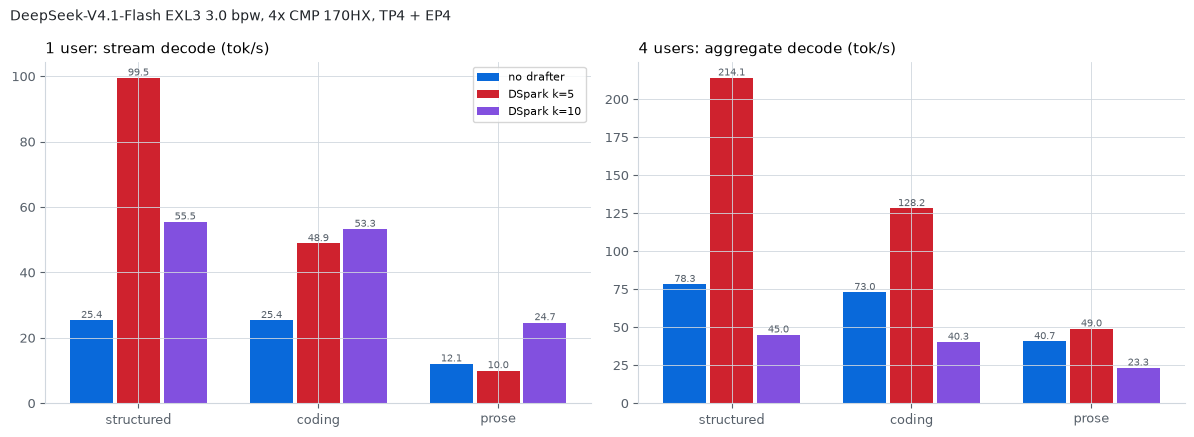

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, c, idx, title in ((axes[0], 1, 0, "1 user: stream decode (tok/s)"), (axes[1], 4, 1, "4 users: aggregate decode (tok/s)")):
    w = 0.26
    for i, (k, lab) in enumerate(VARIANTS):
        bars = ax.bar([j + (i - 1) * w for j in range(3)], [D[(k, p, c)][idx] for p in PROMPTS], w * 0.92, color=S[i], label=lab)
        label_bars(ax, bars)
    ax.set_xticks(range(3), PROMPTS); ax.set_title(title, loc="left")
axes[0].legend(fontsize=8)
fig.suptitle("DeepSeek-V4.1-Flash EXL3 3.0 bpw, 4x CMP 170HX, TP4 + EP4", x=0.01, ha="left", fontsize=10, color=INK)
fig.tight_layout()
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig(f"../assets/charts/{EXPERIMENT}.png", dpi=150); fig.savefig(f"../assets/charts/{EXPERIMENT}.svg")
plt.show()

### 2.2 Draft acceptance

Draft tokens accepted per verify step (the bonus token is not counted), with the acceptance rate in brackets. Structured text accepts almost every DSpark draft; prose accepts about two of five. The k=10 row shows why the second chained pass does not pay.

In [6]:
rows = []
for k, lab in VARIANTS[1:]:
    for c in (1, 4):
        rows.append([lab, c] + [f"{D[(k, p, c)][2]:.2f} ({D[(k, p, c)][3]:.0%})" for p in PROMPTS])
table(["variant", "users", "structured", "code", "prose"], rows)

| variant | users | structured | code | prose |
|---|---:|---:|---:|---:|
| DSpark k=5 | 1 | 4.97 (99%) | 3.71 (74%) | 2.11 (42%) |
| DSpark k=5 | 4 | 4.97 (99%) | 3.60 (72%) | 2.17 (43%) |
| DSpark k=10 | 1 | 3.93 (39%) | 3.71 (37%) | 1.69 (17%) |
| DSpark k=10 | 4 | 3.97 (40%) | 3.30 (33%) | 1.86 (19%) |

### 2.3 Edit reply and correctness

`bench_edit.py`: the model returns a 497-line Python file with one class renamed (T=0). The reply hash is the same with and without the drafter.

In [7]:
rows = []
for k, lab in VARIANTS:
    e = receipt(k, "edit.json")["rename"]
    rows.append([lab, f"{e['tok_s_median']:.1f}", e["tokens"][0], e["shas"][0]])
table(["variant", "tok/s", "reply tokens", "reply sha256 (first 16 hex)"], rows)
c = receipt("correctness.json")
table(["prompt", "expected", "pass", "reply tokens"], [[r["prompt"][:48], r["expect"], r["pass"], r["completion_tokens"]] for r in c["cases"]])
print(f"{c['correct']}/{c['total']} correct (DSpark k=5 server)")

| variant | tok/s | reply tokens | reply sha256 (first 16 hex) |
|---|---:|---:|---:|
| no drafter | 25.1 | 4720 | b755ea88e04201c2 |
| DSpark k=5 | 49.5 | 4720 | b755ea88e04201c2 |
| DSpark k=10 | 49.0 | 4720 | b755ea88e04201c2 |

| prompt | expected | pass | reply tokens |
|---|---:|---:|---:|
| What is 17 * 23? Answer with the number only. | 391 | True | 21 |
| What is the capital of Australia? One word. | Canberra | True | 20 |
| A train leaves at 09:40 and arrives at 13:15. Ho | 215 | True | 47 |
| Write a Python function is_prime(n). Then state  | RESULT=True | True | 225 |
| Spell the word ELEPHANT backwards, uppercase, no | TNAHPELE | True | 62 |

5/5 correct (DSpark k=5 server)


## 3. Prefill and long context

Prompts are real text with a unique nonce (no prefix-cache hits), `max_tokens=1` for prefill. The no-drafter run read the Engram tables cold from NVMe. Before the k=10 run, the tables were faulted into the page cache through mmap; 101 of 189 GiB stayed resident (the filesystem is ZFS; see the appendix). During the cold prefill the four GPUs averaged about 10% utilization and 50 W each: the step waits on the host-side Engram lookup, which every TP rank performs.

In [8]:
rows = []
for k, lab, note in (("no-drafter", "no drafter", "Engram cold"), ("dspark-k10", "DSpark k=10", "Engram ~101/189 GiB in page cache")):
    for r in receipt(k, "prefill.json")["results"]:
        rows.append([lab, note, r["prompt_tokens"], f"{r['ttft_s']:.1f}", f"{r['prefill_tok_s']:.0f}"])
table(["variant", "Engram", "prompt tokens", "TTFT s", "prefill tok/s"], rows)
lc = receipt("no-drafter", "longdecode.json")["results"]
table(["prompt tokens", "TTFT s", "decode tok/s (no drafter)"], [[r["prompt_tokens"], f"{r['ttft_s']:.1f}", f"{r['decode_tok_s']:.1f}"] for r in lc])

| variant | Engram | prompt tokens | TTFT s | prefill tok/s |
|---|---:|---:|---:|---:|
| no drafter | Engram cold | 7113 | 61.9 | 115 |
| no drafter | Engram cold | 7428 | 67.8 | 110 |
| no drafter | Engram cold | 25585 | 196.3 | 130 |
| no drafter | Engram cold | 25779 | 184.4 | 140 |
| no drafter | Engram cold | 51403 | 296.6 | 173 |
| no drafter | Engram cold | 41884 | 243.1 | 172 |
| DSpark k=10 | Engram ~101/189 GiB in page cache | 7112 | 34.8 | 205 |
| DSpark k=10 | Engram ~101/189 GiB in page cache | 7425 | 38.5 | 193 |
| DSpark k=10 | Engram ~101/189 GiB in page cache | 25582 | 91.3 | 280 |
| DSpark k=10 | Engram ~101/189 GiB in page cache | 25781 | 84.1 | 306 |
| DSpark k=10 | Engram ~101/189 GiB in page cache | 51406 | 143.0 | 360 |
| DSpark k=10 | Engram ~101/189 GiB in page cache | 41885 | 118.4 | 354 |

| prompt tokens | TTFT s | decode tok/s (no drafter) |
|---|---:|---:|
| 916 | 2.4 | 13.4 |
| 7531 | 48.2 | 15.4 |
| 28282 | 140.2 | 14.4 |
| 45476 | 145.5 | 14.3 |

## 4. Thermals

Peak core temperature and mean power per run from 2 s `nvidia-smi` samples. This repository's stop rule is 80 °C core.

In [9]:
def telemetry(k):
    rows = list(csv.reader(open(f"{RECEIPTS}/{k}/telemetry.csv"), skipinitialspace=True))[1:]
    temps, power = [], []
    for r in rows:
        try:
            temps.append(float(r[2])); power.append(float(r[3].split()[0]))
        except (ValueError, IndexError):
            pass
    return temps, power
rows = []
for k, lab in VARIANTS:
    t, p = telemetry(k)
    rows.append([lab, f"{max(t):.0f}", f"{statistics.mean(p):.0f}", f"{max(p):.0f}"])
table(["run", "peak core °C", "mean W per card", "peak sampled W (instantaneous; cap 140 W)"], rows)

| run | peak core °C | mean W per card | peak sampled W (instantaneous; cap 140 W) |
|---|---:|---:|---:|
| no drafter | 70 | 64 | 209 |
| DSpark k=5 | 70 | 75 | 186 |
| DSpark k=10 | 70 | 74 | 193 |

## 5. Reproduce

Hardware: 4 × CMP 170HX exposing 65,536 MiB each (64 GiB unlock), forced-air cooling, ~400 GB of disk for the checkpoint and Engram tables. Weights do not fit fewer than four cards.

```bash
# 1. weights (EXL3 checkpoint + Engram shards 47-48)
hf download Mia-AiLab/DeepSeek-V4.1-Flash-EXL3-3.0bpw --revision c5534b90602b4090980a1c3ded1eb3b4d99a38d5 \
  --local-dir /path/to/models/Mia-DeepSeek-V4.1-Flash-EXL3-3.0bpw
hf download deepseek-ai/DeepSeek-V4.1-Flash --revision 2cba9e42aa026125f3ed06c6d98c1db82f7ca027 \
  --include "model-00047-of-00048.safetensors" "model-00048-of-00048.safetensors" "config.json" \
  "model.safetensors.index.json" "inference/engram.py" --local-dir /path/to/models/DeepSeek-V4.1-Flash-engram

# 2. overlay pack (the base image's own prepare step; one card is enough)
docker run --rm --gpus '"device=0"' -v /path/to/models:/models ghcr.io/pixelml/club-170hx@sha256:75683c4813efaabcc1a96ee610a96a74336677c4a8776b79b01abd83ff3c0c7b prepare

# 3. serve: TP4 + EP4, DSpark k=5, port 8040
docker run -d --name dsv41 --gpus all --ulimit memlock=-1 --shm-size 16g -p 8040:8040 \
  -v /path/to/models:/models:ro ghcr.io/pixelml/club-170hx@sha256:ffba0e15b5295204a3860fae7ba93fd70fe94d824f79baa1340ab71fa1f451f8 \
  --speculative-config '{"method":"dspark","num_speculative_tokens":5}'
```

`launch.sh` (in `build/`) holds every serve argument: `--tensor-parallel-size 4 --enable-expert-parallel --quantization exl3 --max-model-len 65536 --max-num-seqs 4 --max-num-batched-tokens 8192 --kv-cache-dtype fp8 --gpu-memory-utilization 0.94 --no-enable-prefix-caching --language-model-only --tokenizer-mode deepseek_v41 --disable-custom-all-reduce`, CUDA graphs for decode sizes 1–24, and the environment (`DSV41_REPLICATE_SHARED=1`, disk Engram tier, empty host-expert plan). Power cap: `nvidia-smi -pl 140`. Bench scripts: `bench_decode.py`, `bench_edit.py`, `bench_long.py` in `results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/`.

## Try your own prompt

Edit `PROMPT`; with `LIVE = False` this prints the recorded known-answer reply instead.

In [10]:
PROMPT = "What is 17 * 23? Answer with the number only."
if LIVE:
    import urllib.request
    url = os.environ[ENDPOINT_ENV_VAR]
    body = {"model": "deepseek-v4.1-flash", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 1500, "temperature": 0}
    req = urllib.request.Request(url + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=900))
    msg = resp["choices"][0]["message"]
    print("reasoning:", (msg.get("reasoning_content") or msg.get("reasoning") or "")[:400]); print("answer:", msg.get("content")); print(resp["usage"])
else:
    case = receipt("correctness.json")["cases"][0]
    print(case["prompt"], "->", case["content"], "| tokens:", case["completion_tokens"])

What is 17 * 23? Answer with the number only. -> 391 | tokens: 21


<details><summary>Appendix: what it took, and what failed</summary>

- **Base recipe is single-GPU.** The 0xSero image serves one 24 GB card with host-offloaded experts; its entrypoint exits with SIGPIPE (code 141) when more than one GPU is visible. `launch.sh` replaces it.
- **TP4 alone fails (measured).** EXL3 tiles rows in 128-row blocks; the shared expert split four ways is 2304 / 4 = 576 rows, and the loader refuses padded multi-shard layers. Fix: expert parallelism for the routed experts, and the shared expert replicated with its output scaled by 1/4 before the MoE all-reduce (exact: 4 is a power of two). The plugin also needed to read the MoE split from the layer's own `moe_parallel_config` (EP keeps experts whole) and to stop slicing `ReplicatedLinear` weights.
- **TP2 × PP2 fails (measured).** Stage 1's KV allocation references compressor state caches of stage-0 layers 2, 8 and 14 (`StopIteration` in `allocate_kv_cache`).
- **The lm_head must split on 128-row boundaries (measured).** 129,280 / 4 = 32,320 rows per rank cuts an EXL3 Hadamard block at each rank boundary; the server then emitted one token forever ("ifiable"), with the four bad token ids all at local row 32,256. Fix: build the head with vocab padding 128 × tp (32,384 rows per rank) and load each rank's exact range from vLLM's shard indices.
- **Disk Engram tier at TP > 1.** Its single-GPU assert is removed; every rank reads all heads from the shared mmap, so each lookup is done four times.
- **DSpark k.** `num_speculative_tokens` must be a multiple of the head's `n_predict` = 5; k=7 is rejected at start-up.
- **ZFS page cache (measured, cause inferred).** After faulting the 189 GiB of Engram tables in through mmap with `MADV_POPULATE_READ`, only 101 GiB stayed cached although the container had ~99 GB free. Model weights earlier plateaued near the same size. Keeping the tables on tmpfs is the next step.
- **Licences.** vllm-exl3 is AGPL-3.0 (with Apache-2.0 parts); the patched `exl3.py` is published in `build/`. The base recipe is MIT, the checkpoint and Engram tables are MIT.
- **PCIe.** One card trained at Gen2 x8 during these runs (the other three x16).
</details>